 ## 1. Load Data

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    precision_recall_curve,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer
from sklearn.base import clone


from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")



In [32]:
df = pd.read_csv("new_df.csv")

target_col = "chagas"

X = df.drop(columns=[target_col])
y = df[target_col]
groups = df["patient_id"]

print("Dataset size:", df.shape)

print("\nTarget variable distribution:")
print(y.value_counts())

print("\nTarget proportions:")
print(y.value_counts(normalize=True))



Dataset size: (342142, 42)

Target variable distribution:
chagas
0    335583
1      6559
Name: count, dtype: int64

Target proportions:
chagas
0    0.98083
1    0.01917
Name: proportion, dtype: float64


 ## 2. Train / Validation / Test Split by Patient

In [33]:
gss1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, temp_idx = next(
    gss1.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_temp = X.iloc[temp_idx].copy()

y_train = y.iloc[train_idx].copy()
y_temp = y.iloc[temp_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_temp = groups.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    gss2.split(X_temp, y_temp, groups=groups_temp)
)

X_val = X_temp.iloc[val_idx].copy()
X_test = X_temp.iloc[test_idx].copy()

y_val = y_temp.iloc[val_idx].copy()
y_test = y_temp.iloc[test_idx].copy()

groups_val = groups_temp.iloc[val_idx].copy()
groups_test = groups_temp.iloc[test_idx].copy()

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)



Train: (239583, 41)
Validation: (51312, 41)
Test: (51247, 41)


 ## 3. Check Patient Overlap Between Splits

In [34]:
train_patients = set(groups_train)
val_patients = set(groups_val)
test_patients = set(groups_test)

train_val_overlap = train_patients & val_patients
train_test_overlap = train_patients & test_patients
val_test_overlap = val_patients & test_patients

print("Train-Val overlap:", len(train_val_overlap))
print("Train-Test overlap:", len(train_test_overlap))
print("Val-Test overlap:", len(val_test_overlap))



Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


 ## 4. Data Preprocessing

In [35]:
drop_cols = [
    "exam_id",
    "patient_id",
    "interval_lead_idx",
    "n_usable_leads"
]

drop_cols = [
    col for col in drop_cols
    if col in X_train.columns
]

X_train = X_train.drop(columns=drop_cols)
X_val = X_val.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

for data_part in [X_train, X_val, X_test]:
    bool_cols = data_part.select_dtypes(include=["bool"]).columns
    data_part[bool_cols] = data_part[bool_cols].astype(int)

object_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("MISSING VALUES BEFORE IMPUTATION")

print("Train:", X_train.isna().sum().sum())
print("Validation:", X_val.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_val = pd.DataFrame(
    imputer.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("MISSING VALUES AFTER IMPUTATION")
print("Train:", X_train.isna().sum().sum())
print("Validation:", X_val.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())

print(f"\nFeatures: {X_train.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")



MISSING VALUES BEFORE IMPUTATION
Train: 3200
Validation: 651
Test: 672
MISSING VALUES AFTER IMPUTATION
Train: 0
Validation: 0
Test: 0

Features: 37
Training samples: 239583


 ## 5. Class Balance Check

In [36]:
print(f"Train positive rate: {y_train.mean():.4f} ({y_train.sum()}/{len(y_train)})")
print(f"Validation positive rate: {y_val.mean():.4f} ({y_val.sum()}/{len(y_val)})")
print(f"Test positive rate: {y_test.mean():.4f} ({y_test.sum()}/{len(y_test)})")


Train positive rate: 0.0186 (4450/239583)
Validation positive rate: 0.0218 (1120/51312)
Test positive rate: 0.0193 (989/51247)


 ## 6. Helper Function for F2 Threshold Selection

In [18]:
def get_best_f2_threshold(y_true, y_prob, beta=2):
    precision, recall, thresholds = precision_recall_curve(
        y_true,
        y_prob
    )

    beta_squared = beta ** 2

    f2_scores = (
        (1 + beta_squared) * precision[:-1] * recall[:-1] /
        (beta_squared * precision[:-1] + recall[:-1] + 1e-9)
    )

    best_idx = np.argmax(f2_scores)

    return {
        "threshold": thresholds[best_idx],
        "f2": f2_scores[best_idx],
        "precision": precision[best_idx],
        "recall": recall[best_idx]
    }



 ## 7. Hyperparameter Tuning with Hold-Out Validation

In [ ]:
param_grid = {
    "n_estimators": [700],
    "max_depth": [15, 25],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 4, 8],
    "max_features": [0.3, 0.5, "sqrt"],
    "class_weight": ["balanced", "balanced_subsample"]
}

total_combinations = len(ParameterGrid(param_grid))



HYPERPARAMETER GRID SEARCH - HOLD-OUT VALIDATION
Parameter combinations: 72 models
Model selection metric: Validation PR-AUC
Threshold selection metric: Validation F2-score
ROC-AUC is reported as an additional discrimination metric



In [ ]:
results = []

best_score = -np.inf
best_model = None
best_params = None
best_threshold = None


for params in tqdm(ParameterGrid(param_grid), total=total_combinations, desc="Grid Search"):

    rf = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    y_val_prob = rf.predict_proba(X_val)[:, 1]
    val_roc_auc = roc_auc_score(y_val, y_val_prob)
    val_pr_auc = average_precision_score(y_val, y_val_prob)

    y_val_pred_default = (y_val_prob >= 0.5).astype(int)

    val_balanced_acc_default = balanced_accuracy_score(
        y_val,
        y_val_pred_default
    )

    val_f1_default = f1_score(
        y_val,
        y_val_pred_default,
        zero_division=0
    )

    val_f2_default = fbeta_score(
        y_val,
        y_val_pred_default,
        beta=2,
        zero_division=0
    )

    val_precision_default = precision_score(
        y_val,
        y_val_pred_default,
        zero_division=0
    )

    val_recall_default = recall_score(
        y_val,
        y_val_pred_default,
        zero_division=0
    )

    threshold_info = get_best_f2_threshold(
        y_val,
        y_val_prob,
        beta=2
    )

    selected_threshold = threshold_info["threshold"]

    y_val_pred_selected = (
        y_val_prob >= selected_threshold
    ).astype(int)

    val_balanced_acc_selected = balanced_accuracy_score(
        y_val,
        y_val_pred_selected
    )

    val_f1_selected = f1_score(
        y_val,
        y_val_pred_selected,
        zero_division=0
    )

    val_f2_selected = fbeta_score(
        y_val,
        y_val_pred_selected,
        beta=2,
        zero_division=0
    )

    val_precision_selected = precision_score(
        y_val,
        y_val_pred_selected,
        zero_division=0
    )

    val_recall_selected = recall_score(
        y_val,
        y_val_pred_selected,
        zero_division=0
    )

    results.append({
        **params,
        "val_roc_auc": val_roc_auc,
        "val_pr_auc": val_pr_auc,

        "threshold_f2": selected_threshold,

        "val_balanced_acc_default_0_5": val_balanced_acc_default,
        "val_f1_default_0_5": val_f1_default,
        "val_f2_default_0_5": val_f2_default,
        "val_precision_default_0_5": val_precision_default,
        "val_recall_default_0_5": val_recall_default,

        "val_balanced_acc_selected": val_balanced_acc_selected,
        "val_f1_selected": val_f1_selected,
        "val_f2_selected": val_f2_selected,
        "val_precision_selected": val_precision_selected,
        "val_recall_selected": val_recall_selected
    })

    if val_pr_auc > best_score:
        best_score = val_pr_auc
        best_model = rf
        best_params = params
        best_threshold = selected_threshold

results_df = (
    pd.DataFrame(results)
    .sort_values("val_pr_auc", ascending=False)
    .reset_index(drop=True)
)


print(f"Best PR-AUC score on validation set: {best_score:.4f}")

print("\nBest parameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

print(f"\nBest threshold selected by validation F2: {best_threshold:.4f}")

print("\nTop 10 hyperparameter combinations by Validation PR-AUC:")

display_cols = (
    list(best_params.keys()) +
    [
        "val_roc_auc",
        "val_pr_auc",
        "threshold_f2",
        "val_balanced_acc_selected",
        "val_f1_selected",
        "val_f2_selected",
        "val_precision_selected",
        "val_recall_selected"
    ]
)

print(results_df[display_cols].head(10).to_string(index=False))



Training models with real-time progress tracking...



Grid Search: 100%|██████████| 72/72 [4:42:42<00:00, 235.59s/it]  


GRID SEARCH RESULTS
Best PR-AUC score on validation set: 0.1467

Best parameters:
  class_weight: balanced
  max_depth: 25
  max_features: sqrt
  min_samples_leaf: 8
  min_samples_split: 5
  n_estimators: 700

Best threshold selected by validation F2: 0.2558

Top 10 hyperparameter combinations by Validation PR-AUC:
      class_weight  max_depth max_features  min_samples_leaf  min_samples_split  n_estimators  val_roc_auc  val_pr_auc  threshold_f2  val_balanced_acc_selected  val_f1_selected  val_f2_selected  val_precision_selected  val_recall_selected
          balanced         25         sqrt                 8                  5           700     0.833099    0.146680      0.255817                   0.663809         0.212412         0.287411                0.148031             0.375893
          balanced         25         sqrt                 8                 10           700     0.833099    0.146680      0.255817                   0.663809         0.212412         0.287411           

 ## 8. Best Model Evaluation on Validation Set

In [ ]:
y_val_prob_best = best_model.predict_proba(X_val)[:, 1]

y_val_pred_default = (y_val_prob_best >= 0.5).astype(int)
y_val_pred_selected = (y_val_prob_best >= best_threshold).astype(int)

val_roc_auc = roc_auc_score(y_val, y_val_prob_best)
val_pr_auc = average_precision_score(y_val, y_val_prob_best)

val_balanced_acc_default = balanced_accuracy_score(
    y_val,
    y_val_pred_default
)

val_f1_default = f1_score(
    y_val,
    y_val_pred_default,
    zero_division=0
)

val_f2_default = fbeta_score(
    y_val,
    y_val_pred_default,
    beta=2,
    zero_division=0
)

val_precision_default = precision_score(
    y_val,
    y_val_pred_default,
    zero_division=0
)

val_recall_default = recall_score(
    y_val,
    y_val_pred_default,
    zero_division=0
)

val_balanced_acc_selected = balanced_accuracy_score(
    y_val,
    y_val_pred_selected
)

val_f1_selected = f1_score(
    y_val,
    y_val_pred_selected,
    zero_division=0
)

val_f2_selected = fbeta_score(
    y_val,
    y_val_pred_selected,
    beta=2,
    zero_division=0
)

val_precision_selected = precision_score(
    y_val,
    y_val_pred_selected,
    zero_division=0
)

val_recall_selected = recall_score(
    y_val,
    y_val_pred_selected,
    zero_division=0
)

print(f"Selected threshold by validation F2: {best_threshold:.4f}")
print(f"ROC-AUC: {val_roc_auc:.4f}")
print(f"PR-AUC: {val_pr_auc:.4f}")

print("\nDefault threshold 0.5:")
print(f"Balanced Accuracy: {val_balanced_acc_default:.4f}")
print(f"F1-score: {val_f1_default:.4f}")
print(f"F2-score: {val_f2_default:.4f}")
print(f"Precision: {val_precision_default:.4f}")
print(f"Recall: {val_recall_default:.4f}")
print(confusion_matrix(y_val, y_val_pred_default))

print("\nSelected threshold by F2:")
print(f"Balanced Accuracy: {val_balanced_acc_selected:.4f}")
print(f"F1-score: {val_f1_selected:.4f}")
print(f"F2-score: {val_f2_selected:.4f}")
print(f"Precision: {val_precision_selected:.4f}")
print(f"Recall: {val_recall_selected:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_selected, digits=4, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_selected))



VALIDATION SET PERFORMANCE - BEST RANDOM FOREST
Selected threshold by validation F2: 0.2558
ROC-AUC: 0.8331
PR-AUC: 0.1467

Default threshold 0.5:
Balanced Accuracy: 0.5536
F1-score: 0.1666
F2-score: 0.1293
Precision: 0.3206
Recall: 0.1125
[[49925   267]
 [  994   126]]

Selected threshold by F2:
Balanced Accuracy: 0.6638
F1-score: 0.2124
F2-score: 0.2874
Precision: 0.1480
Recall: 0.3759

Classification Report:
              precision    recall  f1-score   support

           0     0.9856    0.9517    0.9684     50192
           1     0.1480    0.3759    0.2124      1120

    accuracy                         0.9392     51312
   macro avg     0.5668    0.6638    0.5904     51312
weighted avg     0.9673    0.9392    0.9519     51312


Confusion Matrix:
[[47769  2423]
 [  699   421]]


 ## 9. Test Set Evaluation

In [ ]:
y_test_prob_best = best_model.predict_proba(X_test)[:, 1]

y_test_pred_default = (y_test_prob_best >= 0.5).astype(int)
y_test_pred_selected = (y_test_prob_best >= best_threshold).astype(int)

test_roc_auc = roc_auc_score(y_test, y_test_prob_best)
test_pr_auc = average_precision_score(y_test, y_test_prob_best)

test_balanced_acc_default = balanced_accuracy_score(
    y_test,
    y_test_pred_default
)

test_f1_default = f1_score(
    y_test,
    y_test_pred_default,
    zero_division=0
)

test_f2_default = fbeta_score(
    y_test,
    y_test_pred_default,
    beta=2,
    zero_division=0
)

test_precision_default = precision_score(
    y_test,
    y_test_pred_default,
    zero_division=0
)

test_recall_default = recall_score(
    y_test,
    y_test_pred_default,
    zero_division=0
)

test_balanced_acc_selected = balanced_accuracy_score(
    y_test,
    y_test_pred_selected
)

test_f1_selected = f1_score(
    y_test,
    y_test_pred_selected,
    zero_division=0
)

test_f2_selected = fbeta_score(
    y_test,
    y_test_pred_selected,
    beta=2,
    zero_division=0
)

test_precision_selected = precision_score(
    y_test,
    y_test_pred_selected,
    zero_division=0
)

test_recall_selected = recall_score(
    y_test,
    y_test_pred_selected,
    zero_division=0
)

print(f"Selected threshold from validation set: {best_threshold:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")
print(f"PR-AUC: {test_pr_auc:.4f}")

print("\nDefault threshold 0.5:")
print(f"Balanced Accuracy: {test_balanced_acc_default:.4f}")
print(f"F1-score: {test_f1_default:.4f}")
print(f"F2-score: {test_f2_default:.4f}")
print(f"Precision: {test_precision_default:.4f}")
print(f"Recall: {test_recall_default:.4f}")
print(confusion_matrix(y_test, y_test_pred_default))

print("\nSelected threshold by F2:")
print(f"Balanced Accuracy: {test_balanced_acc_selected:.4f}")
print(f"F1-score: {test_f1_selected:.4f}")
print(f"F2-score: {test_f2_selected:.4f}")
print(f"Precision: {test_precision_selected:.4f}")
print(f"Recall: {test_recall_selected:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_selected, digits=4, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_selected))



TEST SET PERFORMANCE - BEST RANDOM FOREST
Selected threshold from validation set: 0.2558
ROC-AUC: 0.8226
PR-AUC: 0.1371

Default threshold 0.5:
Balanced Accuracy: 0.5555
F1-score: 0.1679
F2-score: 0.1326
Precision: 0.3018
Recall: 0.1163
[[49992   266]
 [  874   115]]

Selected threshold by F2:
Balanced Accuracy: 0.6585
F1-score: 0.1897
F2-score: 0.2668
Precision: 0.1281
Recall: 0.3660

Classification Report:
              precision    recall  f1-score   support

           0     0.9871    0.9510    0.9687     50258
           1     0.1281    0.3660    0.1897       989

    accuracy                         0.9397     51247
   macro avg     0.5576    0.6585    0.5792     51247
weighted avg     0.9705    0.9397    0.9536     51247


Confusion Matrix:
[[47793  2465]
 [  627   362]]


 ## 10. Feature Importance Analysis

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)


print(feature_importance.head(20).to_string(index=False))



TOP 20 MOST IMPORTANT FEATURES
             Feature  Importance
                 age    0.085951
     peak_count_mean    0.079984
energy_detail_1_mean    0.061120
energy_detail_2_mean    0.056845
                RBBB    0.049931
  energy_approx_mean    0.046038
         qt_interval    0.036196
        rr_mean_mean    0.034084
    total_power_mean    0.030116
     total_power_std    0.028787
energy_detail_3_mean    0.028279
         pr_interval    0.027905
      hrv_rmssd_mean    0.025740
                sdnn    0.025708
 energy_detail_2_std    0.025103
energy_detail_5_mean    0.025084
 energy_detail_1_std    0.024939
         rr_mean_std    0.024657
         rr_std_mean    0.024447
 energy_detail_4_std    0.023986


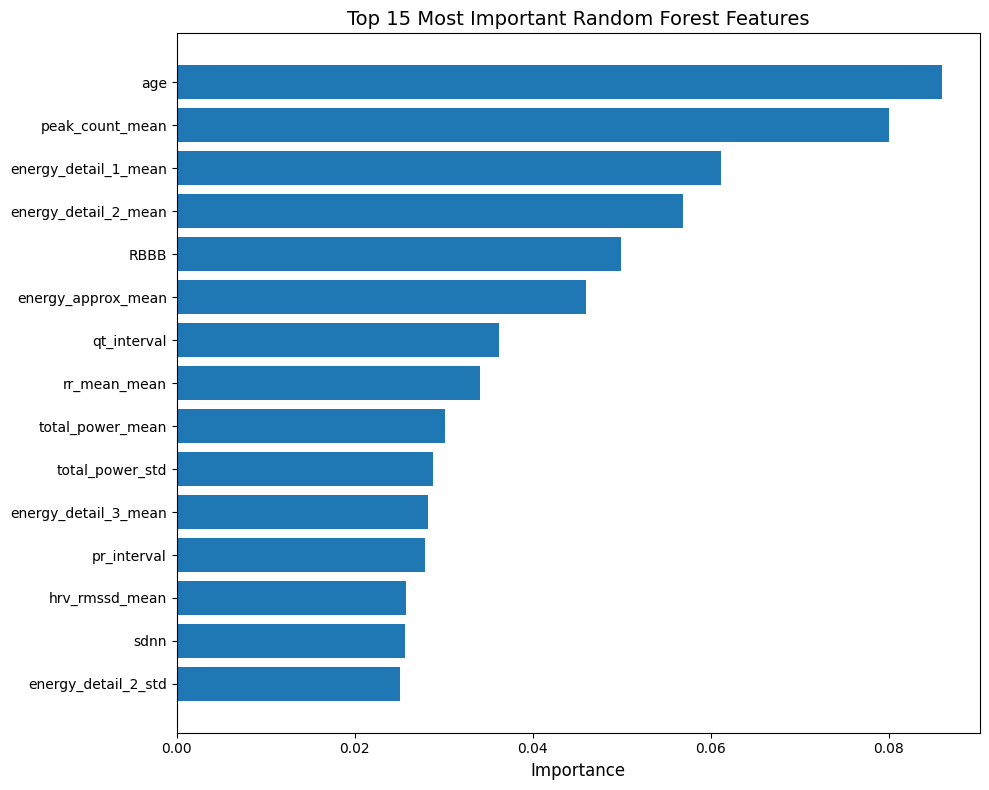

In [24]:
plt.figure(figsize=(10, 8))

top_features = feature_importance.head(15)

plt.barh(range(len(top_features)), top_features["Importance"])
plt.yticks(range(len(top_features)), top_features["Feature"])
plt.xlabel("Importance", fontsize=12)
plt.title("Top 15 Most Important Random Forest Features", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



 ## 11. Final Model Summary

In [ ]:
summary_df = pd.DataFrame({
    "Dataset": [
        "Validation - default threshold 0.5",
        "Validation - selected threshold by F2",
        "Test - default threshold 0.5",
        "Test - selected threshold by F2"
    ],
    "Threshold": [
        0.5,
        best_threshold,
        0.5,
        best_threshold
    ],
    "ROC-AUC": [
        val_roc_auc,
        val_roc_auc,
        test_roc_auc,
        test_roc_auc
    ],
    "PR-AUC": [
        val_pr_auc,
        val_pr_auc,
        test_pr_auc,
        test_pr_auc
    ],
    "Balanced Accuracy": [
        val_balanced_acc_default,
        val_balanced_acc_selected,
        test_balanced_acc_default,
        test_balanced_acc_selected
    ],
    "F1-score": [
        val_f1_default,
        val_f1_selected,
        test_f1_default,
        test_f1_selected
    ],
    "F2-score": [
        val_f2_default,
        val_f2_selected,
        test_f2_default,
        test_f2_selected
    ],
    "Precision": [
        val_precision_default,
        val_precision_selected,
        test_precision_default,
        test_precision_selected
    ],
    "Recall": [
        val_recall_default,
        val_recall_selected,
        test_recall_default,
        test_recall_selected
    ]
})

print(summary_df.to_string(index=False))

print("\nBest hyperparameters selected by validation PR-AUC:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

print(f"\nSelected threshold by validation F2: {best_threshold:.4f}")

print("\nTop 10 hyperparameter combinations by validation PR-AUC:")
print(results_df[display_cols].head(10).to_string(index=False))

FINAL RANDOM FOREST PERFORMANCE SUMMARY
                              Dataset  Threshold  ROC-AUC   PR-AUC  Balanced Accuracy  F1-score  F2-score  Precision   Recall
   Validation - default threshold 0.5   0.500000 0.833099 0.146680           0.553590  0.166557  0.129284   0.320611 0.112500
Validation - selected threshold by F2   0.255817 0.833099 0.146680           0.663809  0.212412  0.287411   0.148031 0.375893
         Test - default threshold 0.5   0.500000 0.822636 0.137117           0.555493  0.167883  0.132580   0.301837 0.116279
      Test - selected threshold by F2   0.255817 0.822636 0.137117           0.658490  0.189727  0.266844   0.128051 0.366026

Best hyperparameters selected by validation PR-AUC:
  class_weight: balanced
  max_depth: 25
  max_features: sqrt
  min_samples_leaf: 8
  min_samples_split: 5
  n_estimators: 700

Selected threshold by validation F2: 0.2558

Top 10 hyperparameter combinations by validation PR-AUC:
      class_weight  max_depth max_features  min

In [42]:
rf_predictions = pd.DataFrame({
    "exam_id": df.loc[X_test.index, "exam_id"] if "exam_id" in df.columns else X_test.index,
    "y_true": y_test.values,
    "y_prob_rf": y_test_prob_best
})

rf_predictions.to_csv("rf_test_predictions.csv", index=False)

## 12. Learning curves

In [ ]:
train_sizes = [0.1, 0.25, 0.5, 0.75, 1.0]

learning_curve_results = []

for size in train_sizes:
    if size < 1.0:
        gss = GroupShuffleSplit(
            n_splits=1,
            train_size=size,
            random_state=42
        )

        subset_idx, _ = next(
            gss.split(
                X_train,
                y_train,
                groups=groups_train
            )
        )

        X_train_part = X_train.iloc[subset_idx].copy()
        y_train_part = y_train.iloc[subset_idx].copy()

    else:
        X_train_part = X_train.copy()
        y_train_part = y_train.copy()

    model = clone(best_model)
    model.fit(X_train_part, y_train_part)

    y_train_prob = model.predict_proba(X_train_part)[:, 1]
    y_val_prob = model.predict_proba(X_val)[:, 1]

    train_pr_auc = average_precision_score(y_train_part, y_train_prob)
    val_pr_auc = average_precision_score(y_val, y_val_prob)

    learning_curve_results.append({
        "train_fraction": size,
        "n_train_samples": len(X_train_part),
        "n_positive_train": int(y_train_part.sum()),
        "train_pr_auc": train_pr_auc,
        "val_pr_auc": val_pr_auc
    })

learning_curve_df = pd.DataFrame(learning_curve_results)

print(learning_curve_df)

   train_fraction  n_train_samples  n_positive_train  train_pr_auc  val_pr_auc
0            0.10            24032               432      0.988552    0.117758
1            0.25            60101              1142      0.989547    0.135482
2            0.50           119699              2265      0.981086    0.142136
3            0.75           179761              3354      0.957262    0.143994
4            1.00           239583              4450      0.952341    0.146680


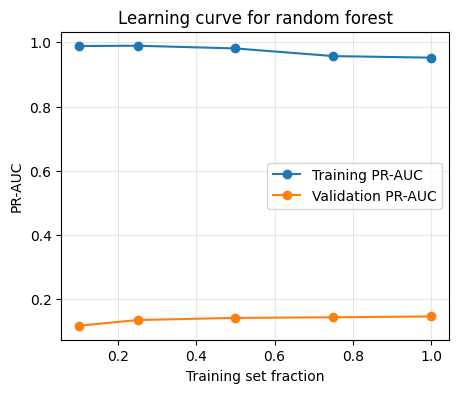

In [30]:
plt.figure(figsize=(5, 4))

plt.plot(
    learning_curve_df["train_fraction"],
    learning_curve_df["train_pr_auc"],
    marker="o",
    label="Training PR-AUC"
)

plt.plot(
    learning_curve_df["train_fraction"],
    learning_curve_df["val_pr_auc"],
    marker="o",
    label="Validation PR-AUC"
)

plt.xlabel("Training set fraction")
plt.ylabel("PR-AUC")
plt.title("Learning curve for random forest")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()